# Итоговое задание по предмету "Анализ временных рядов"
## Морина Ильи Олеговича

# Задача №1.
## Задача Подготовка собственного набора данных и проведение его предварительного анализа.

## 1.1. Выбор датасета

Для выполнения задания был выбран датасет из Kaggle:  
[House Property Sales Time Series](https://www.kaggle.com/datasets/htagholdings/property-sales).

## 1.2. Анализ предметной задачи
### 1.2.1. Данные и целевая величина

Исходя из структуры исходного файла, видно, что используются следующие поля:

- `saledate` — дата продажи (квартальные даты вроде `31/03/2010`).
- `MA` — средняя цена/стоимость (можно трактовать как среднюю цену продажи).
- `type` — тип объекта (`house`, `unit`).
- `bedrooms` — количество спален (для домов 2–5, для юнитов 1–2).

Данные описывают динамику средней цены недвижимости по типу объекта (дом/юнит) и количеству спален по кварталам за несколько лет.

**Цель анализа** — исследовать временной ряд средней цены и подготовить его к последующему прогнозированию.

Для более детального и интерпретируемого анализа была выбрана одна конкретная серия:

> `type = 'house'` и `bedrooms = 3` — временной ряд «средняя цена домов с 3 спальнями по кварталам».

### 1.2.2. Горизонт прогнозирования

В рамках работы рассматривается задача прогнозирования средней квартальной цены домов с 3 спальнями на один–два квартала вперёд.

Такой горизонт выбран потому, что участники рынка недвижимости обычно принимают решения и планируют стратегии на горизонте до одного года, а квартальная детализация хорошо согласуется с этим масштабом планирования.

### 1.2.3. Глобальная vs локальная модель

В данной части работы рассматривается **локальная модель**: анализируется и подготавливается временной ряд для одной комбинации признаков (дома, 3 спальни).

На последующих этапах проект может быть расширен до **глобальной модели**, обучаемой на всех сочетаниях типа недвижимости и числа спален, что позволит использовать общие закономерности для разных сегментов рынка.

### 1.2.4. Онлайн и офлайн прогнозирование

В проекте рассматривается **офлайн-сценарий прогнозирования**: модель обучается на исторических данных и при необходимости переобучается при появлении новых наблюдений.

Онлайн‑обновление параметров модели в режиме реального времени в рамках данной работы не рассматривается, поскольку для учебной задачи достаточно офлайн-подхода.

### 1.2.5. Метрики качества

Для оценки качества последующих прогнозов планируется использовать регрессионные метрики:

- **MAE** (Mean Absolute Error) — средняя абсолютная ошибка;
- **RMSE** (Root Mean Squared Error) — корень из среднеквадратичной ошибки;
- **MAPE** (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка.

Выбор этих метрик обусловлен тем, что целевая переменная (цена) является непрерывной, а относительная ошибка (MAPE) удобна для интерпретации в процентах, что важно для анализа динамики стоимости недвижимости.


## 1.3. Представление данных в машиночитаемом виде и базовый анализ

В этой секции данные из CSV‑файла `house_property_timeseries.csv` приводятся к удобному для анализа формату с использованием библиотеки `pandas`. Выполняется проверка типов данных, пропусков и формирование временного индекса на основе столбца `saledate`.

### 1.3.1. Загрузка данных и первичный осмотр

In [159]:
import pandas as pd

df = pd.read_csv("house_property_timeseries.csv")

df.head()

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   saledate  347 non-null    object
 1   MA        347 non-null    int64 
 2   type      347 non-null    object
 3   bedrooms  347 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.0+ KB


In [161]:
df.columns

Index(['saledate', 'MA', 'type', 'bedrooms'], dtype='object')

Из вывода программы видно, что датасет содержит **347 записей** и **не имеет пропусков** в данных.  
Столбцы имеют следующие типы:

- `saledate` — тип `object` (строковое представление даты);
- `MA` — тип `int64` (целочисленное значение средней цены);
- `type` — тип `object` (категориальный признак: дом или юнит);
- `bedrooms` — тип `int64` (целочисленное количество спален).

Таким образом, исходные данные полностью загружены в датафрейм `pandas`, все строки заполнены, а типы столбцов корректно определены для дальнейшего преобразования и анализа.

### 1.3.2. Формирование временного индекса и готовность данных к анализу

In [162]:
df['saledate'] = pd.to_datetime(df['saledate'], dayfirst=True)
df = df.sort_values('saledate')
df = df.set_index('saledate')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 347 entries, 2007-03-31 to 2019-09-30
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   MA        347 non-null    int64 
 1   type      347 non-null    object
 2   bedrooms  347 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 10.8+ KB


,MA,type,bedrooms
saledate,,,
2007-03-31,421291,house,3
2007-03-31,548969,house,4
2007-06-30,421291,house,3
2007-06-30,368817,unit,2
2007-06-30,548969,house,4


На данном этапе столбец `saledate` был преобразован к типу `datetime` с учётом формата день/месяц/год, после чего данные отсортированы по дате, а `saledate` установлен в качестве индекса датафрейма.

Вывод метода `info()` показывает, что:

- индекс датафрейма имеет тип `DatetimeIndex` и покрывает период с 2007‑03‑31 по 2019‑09‑30;
- в данных содержится 347 наблюдений;
- все столбцы (`MA`, `type`, `bedrooms`) не имеют пропусков;
- числовые признаки (`MA`, `bedrooms`) имеют тип `int64`, категориальный признак `type` представлен строками.

Таким образом, исходные данные приведены к машино‑читаемому виду с корректным временным индексом и готовы к исследовательскому анализу как временной ряд.

## 1.4. EDA временного ряда

После приведения исходных данных к машино‑читаемому виду выполняется исследовательский анализ временного ряда (EDA).  
Цель данного этапа — изучить структуру ряда, выявить его ключевые особенности и подготовить данные к последующему прогнозированию.

В рамках EDA необходимо:

- выбрать конкретный временной ряд для анализа;
- визуализировать динамику ряда во времени;
- исследовать распределение значений;
- оценить наличие тренда и сезонности;
- проанализировать стационарность ряда;
- выполнить преобразование ряда к приближённо стационарному виду;
- сохранить подготовленные данные для дальнейшего моделирования.

### 1.4.1. Выбор временного ряда для анализа

Для проведения EDA был выбран один конкретный сегмент рынка недвижимости:

- `type = house`
- `bedrooms = 3`

Таким образом, объектом дальнейшего анализа является временной ряд средней квартальной цены домов с тремя спальнями.

Выбор одной серии позволяет упростить интерпретацию результатов и сосредоточиться на анализе структуры ряда без усложнения задачи множеством параллельных временных рядов.

In [163]:
ts = df[(df['type'] == 'house') & (df['bedrooms'] == 3)].copy()
ts = ts[['MA']]

ts.info()
ts.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 51 entries, 2007-03-31 to 2019-09-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   MA      51 non-null     int64
dtypes: int64(1)
memory usage: 816.0 bytes


,MA
saledate,
2007-03-31,421291
2007-06-30,421291
2007-09-30,421291
2007-12-31,421291
2008-03-31,416031


В результате фильтрации получен одномерный временной ряд средней квартальной цены домов с тремя спальнями.  
Ряд содержит 51 наблюдение за период 2007–2019 годов, представлен без пропусков и готов к дальнейшему EDA.

### 1.4.2. Визуализация временного ряда

На первом этапе EDA построим график временного ряда средней квартальной цены домов с тремя спальнями.

График позволяет визуально оценить:

- общую динамику изменения цены во времени;
- наличие долгосрочного тренда;
- локальные колебания и возможные аномалии;
- признаки сезонного поведения ряда.

По графику можно сделать предварительный вывод о том, что ряд не является случайным шумом, а содержит выраженную временную структуру, характерную для экономических показателей рынка недвижимости.

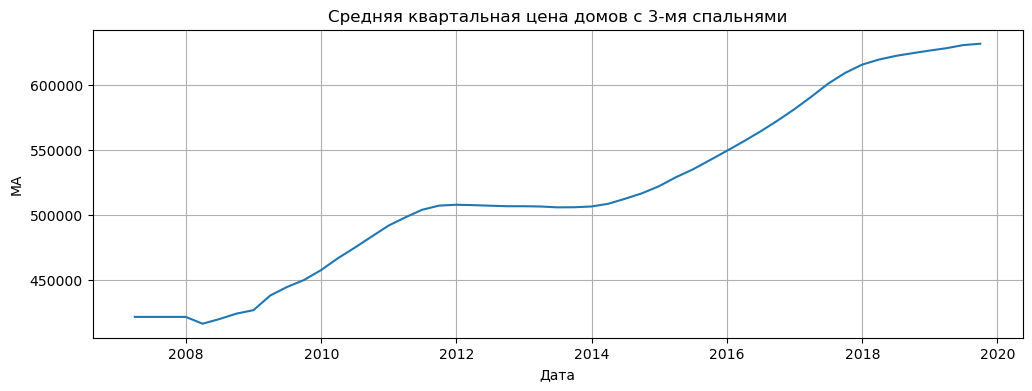

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
sns.lineplot(data=ts, x=ts.index, y='MA')
plt.title('Средняя квартальная цена домов с 3-мя спальнями')
plt.xlabel('Дата')
plt.ylabel('MA')
plt.grid(True)
plt.show()

График средней квартальной стоимости домов с тремя спальнями демонстрирует выраженный возрастающий тренд на всём диапазоне наблюдений.  
В период с 2007 по 2012 год рост относительно плавный, после чего, начиная примерно с 2013–2014 годов, темп увеличения цен ускоряется, и к 2019 году средняя цена достигает максимальных значений.

Явно выраженной регулярной сезонности на уровне кварталов по графику не наблюдается: колебания вокруг тренда относительно небольшие и не образуют чётко повторяющегося годового паттерна.  
Таким образом, основной особенностью данного временного ряда является устойчивый долгосрочный рост цен при умеренных внутригодовом колебаниях.

### 1.4.3. Распределение значений и описательная статистика

Для дополнительного анализа временного ряда исследуется распределение значений целевой переменной `MA`.  
Для этого строится гистограмма и рассчитываются основные статистические показатели.

Такой анализ позволяет:

- определить диапазон изменения средней цены;
- сравнить среднее значение и медиану;
- оценить симметричность распределения;
- выявить возможные выбросы.

Описательная статистика служит базой для понимания масштаба ряда и помогает оценить необходимость дополнительных преобразований данных.

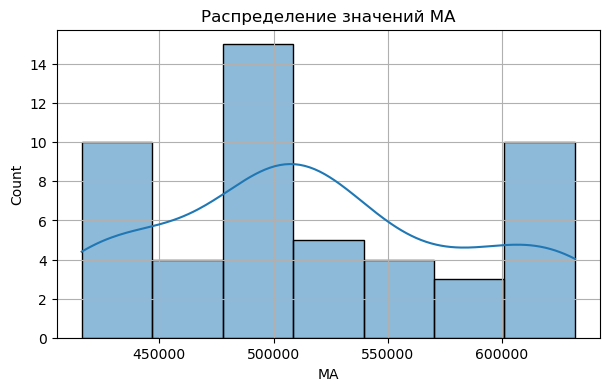

count        51.000000
mean     518357.745098
std       67587.622725
min      416031.000000
25%      470511.500000
50%      507090.000000
75%      568424.500000
max      631875.000000
Name: MA, dtype: float64

In [165]:
plt.figure(figsize=(7, 4))
sns.histplot(ts['MA'], kde=True)
plt.title('Распределение значений MA')
plt.xlabel('MA')
plt.grid(True)
plt.show()

ts['MA'].describe()

Распределение значений средней квартальной цены `MA` для домов с тремя спальнями сосредоточено в диапазоне примерно от 416 тыс. до 632 тыс. единиц.  
Среднее значение составляет около 518 тыс., медиана — около 507 тыс., что говорит о небольшом смещении распределения в сторону более высоких значений.

Интервал между первым и третьим квартилями (от ≈470 тыс. до ≈568 тыс.) показывает, что основная масса наблюдений лежит в относительно узком диапазоне вокруг среднего.  
Выраженных экстремальных выбросов не наблюдается, поэтому распределение можно считать достаточно устойчивым и пригодным для дальнейшего моделирования без дополнительного удаления аномалий.

### 1.4.4. Анализ тренда и изменчивости ряда

Для оценки стационарности временного ряда были рассчитаны:

- скользящее среднее;
- скользящее стандартное отклонение.

В качестве окна выбрано значение 4, что соответствует одному году наблюдений (4 квартала).

Если временной ряд является стационарным, его среднее значение и дисперсия должны оставаться приблизительно постоянными во времени.  
Изменение скользящего среднего указывает на наличие тренда, а изменение скользящего стандартного отклонения — на нестабильность дисперсии.

Таким образом, данный шаг позволяет предварительно оценить, требуется ли преобразование ряда перед применением методов прогнозирования.

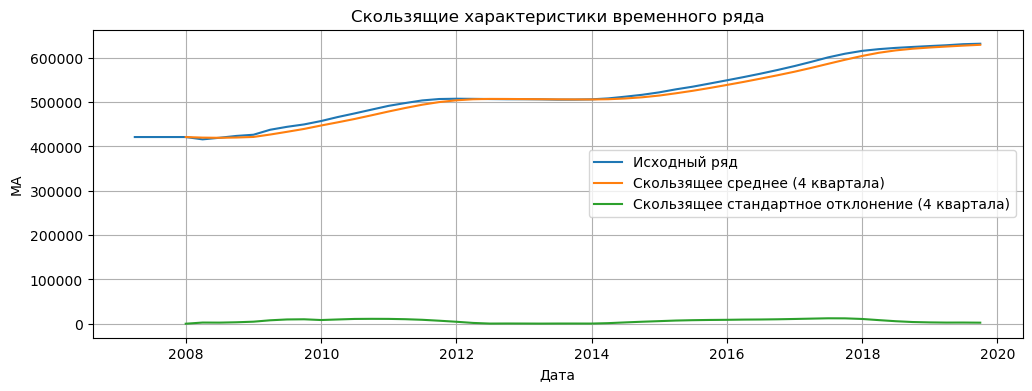

In [166]:
window = 4  # 4 квартала = 1 год

rolling_mean = ts['MA'].rolling(window=window).mean()
rolling_std = ts['MA'].rolling(window=window).std()

plt.figure(figsize=(12, 4))
plt.plot(ts['MA'], label='Исходный ряд')
plt.plot(rolling_mean, label='Скользящее среднее (4 квартала)')
plt.plot(rolling_std, label='Скользящее стандартное отклонение (4 квартала)')
plt.title('Скользящие характеристики временного ряда')
plt.xlabel('Дата')
plt.ylabel('MA')
plt.legend()
plt.grid(True)
plt.show()

График скользящих характеристик показывает, что скользящее среднее по окну в 4 квартала практически повторяет форму исходного ряда и монотонно растёт на всём интервале наблюдений.  
Это подтверждает наличие устойчивого положительного тренда в динамике средней квартальной цены домов с тремя спальнями.

Скользящее стандартное отклонение остаётся на сравнительно низком уровне и изменяется значительно менее резко, чем сам ряд.  
Следовательно, основное изменение во времени связано именно с ростом уровня цен, тогда как разброс значений вокруг тренда остаётся относительно стабильным, что дополнительно указывает на нестационарность ряда по среднему при более или менее устойчивой дисперсии.

### 1.4.5. Декомпозиция временного ряда

Для более детального анализа структуры временного ряда применяется декомпозиция на компоненты:

- тренд;
- сезонность;
- остаток.

Поскольку данные имеют квартальную частоту, в качестве периода используется значение 4, что соответствует одному году.

Декомпозиция позволяет:

- выделить долгосрочное направление изменения цен;
- определить наличие повторяющихся сезонных колебаний;
- отделить случайную составляющую от систематической структуры ряда.

По результатам декомпозиции можно сделать вывод о том, насколько выражены тренд и сезонность, а также насколько сложной является структура исследуемого временного ряда.

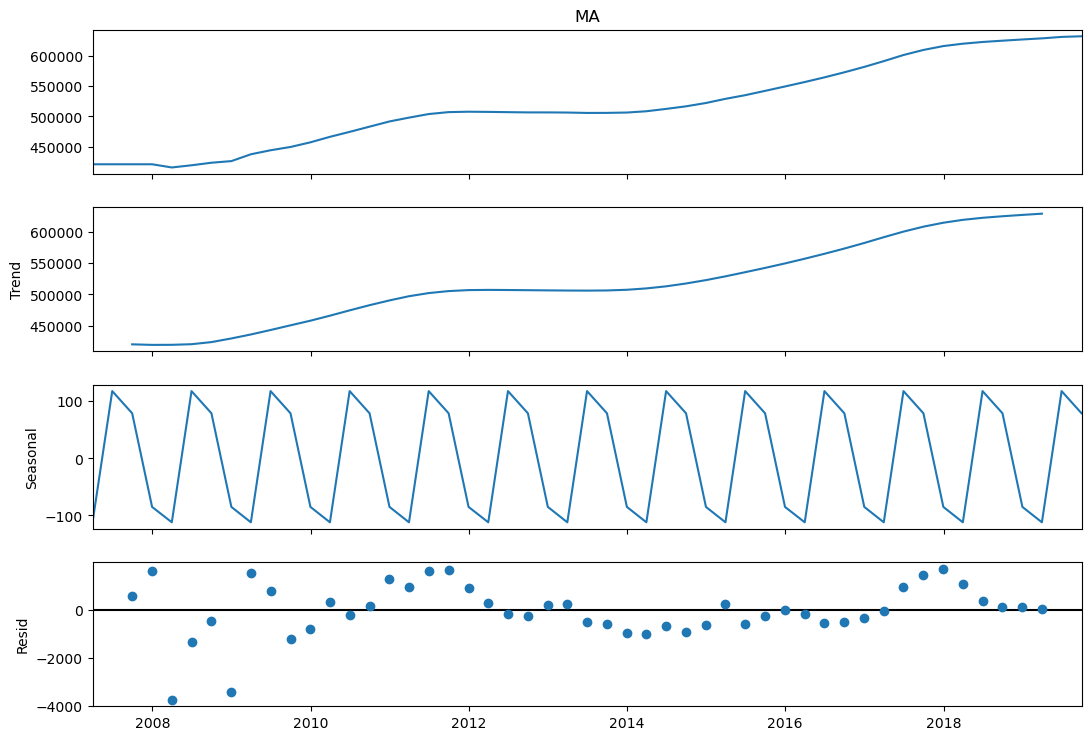

In [167]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts['MA'], model='additive', period=4)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

Декомпозиция временного ряда показывает, что основную структуру `MA` формирует чётко выраженный положительный тренд: трендовая компонента монотонно растёт на всём интервале наблюдений.  
Это подтверждает ранее сделанный вывод о долгосрочном устойчивом росте средней квартальной цены домов с тремя спальнями.

Сезонная компонента демонстрирует регулярные колебания с периодом в 4 квартала, то есть в ряду присутствует годовая сезонность, однако её амплитуда существенно меньше уровня тренда.  
Остаточная компонента колеблется вокруг нулевой линии без ярко выраженных структурных сдвигов, что говорит об отсутствии сильных нерегулярных эффектов после учёта тренда и сезонности.

### 1.4.6. Сведение ряда к стационарному виду

Для многих классических моделей временных рядов требуется стационарность ряда, то есть относительная стабильность среднего значения и дисперсии во времени.

С этой целью были выполнены два преобразования:

1. Логарифмирование ряда `MA`, которое уменьшает влияние масштаба и сглаживает рост значений.
2. Вычисление первой разности логарифмированного ряда, что позволяет ослабить тренд.

Полученный преобразованный ряд является более устойчивым по сравнению с исходным и может рассматриваться как приближённо стационарный.

Данный шаг является важной частью подготовки данных к последующему построению статистических моделей прогнозирования.

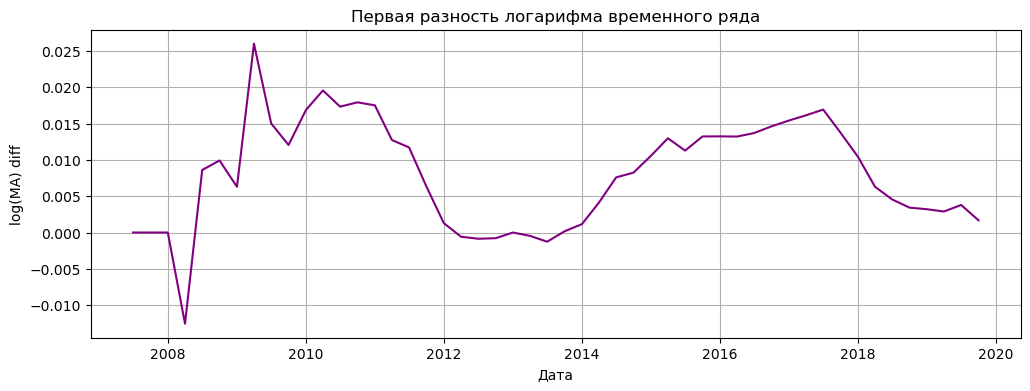

In [168]:
import numpy as np

ts['MA_log'] = np.log(ts['MA'])
ts['MA_log_diff'] = ts['MA_log'].diff()

plt.figure(figsize=(12, 4))
plt.plot(ts['MA_log_diff'], color='purple')
plt.title('Первая разность логарифма временного ряда')
plt.xlabel('Дата')
plt.ylabel('log(MA) diff')
plt.grid(True)
plt.show()

После логарифмирования исходного ряда и вычисления первой разности значения временного ряда колеблются вокруг нулевого уровня без выраженного долгосрочного тренда.  
Амплитуда колебаний остается относительно стабильной на большей части интервала наблюдений, что свидетельствует о выравнивании дисперсии по сравнению с исходным рядом.

Таким образом, преобразованный ряд первой разности логарифма можно рассматривать как приближённо стационарный.  
Это позволяет использовать его в качестве основы для построения классических статистических моделей временных рядов, предполагающих стационарность данных.

### 1.4.7. Сохранение подготовленных данных

По результатам проведённого EDA был сформирован подготовленный набор данных, включающий:

- исходные значения средней квартальной цены `MA`;
- логарифмированные значения `MA_log`;
- первую разность логарифмированного ряда `MA_log_diff`.

Подготовленный временной ряд был сохранён в файл `house_property_ts_prepared.csv` для дальнейшего использования при построении и сравнении моделей прогнозирования.

In [169]:
prepared_ts = ts.copy()
prepared_ts.to_csv('house_property_ts_prepared.csv')

## 1.5. Выводы по EDA

В результате исследовательского анализа временного ряда были получены следующие результаты:

- выбран и выделен временной ряд средней квартальной цены домов с тремя спальнями;
- построены основные визуализации ряда и исследовано распределение значений;
- выполнен анализ тренда и изменчивости ряда с помощью скользящих характеристик;
- проведена декомпозиция ряда на тренд, сезонность и остаточную компоненту;
- выполнено преобразование ряда к приближённо стационарному виду;
- подготовленные данные сохранены для последующего этапа моделирования.

Таким образом, временной ряд исследован, его основные особенности выявлены, а данные подготовлены к дальнейшему применению методов прогнозирования временных рядов.

# Задача №2.

## Задача Освоение наиболее популярных инструментов АВР, и обоснованный выбор методов статистических методов анализа ВР.

## 2.1. Изучить фреймворк statsforecast

### 2.1.1. Подготовка и установка

In [170]:
!pip install statsforecast

In [171]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA, AutoETS, Theta, SeasonalNaive

### 2.1.2. Модели статистического прогнозирования

Во второй части работы рассматриваются классические статистические методы прогнозирования временных рядов, реализованные во фреймворке `statsforecast`.  
Целью данного этапа является сравнение нескольких моделей прогнозирования на выбранном временном ряде и обоснованный выбор наиболее подходящего подхода на основе метрик качества и дополнительных диагностических процедур.

В качестве объекта анализа используется временной ряд средней квартальной цены домов с тремя спальнями, подготовленный в рамках первой задачи.

### 2.1.3. Цель и постановка задачи

Основная цель этой части работы — изучить возможности библиотеки `statsforecast` и применить её для решения задачи краткосрочного прогнозирования временного ряда.

Для достижения этой цели необходимо:

- подготовить временной ряд в формате, требуемом библиотекой `statsforecast`;
- изучить и применить несколько статистических моделей прогнозирования;
- сравнить модели как в ручном, так и в автоматическом режимах подбора параметров;
- провести обоснованный выбор лучшего метода на основе бэктестинга, анализа ошибок и анализа остатков.

Горизонт прогнозирования в рамках данной задачи сохраняется таким же, как и в первой части работы: **1–2 квартала вперёд**.

### 2.1.4. Выбор инструмента `statsforecast`

Для построения статистических моделей прогнозирования используется библиотека `statsforecast`, предназначенная для быстрого и удобного применения популярных методов анализа временных рядов.

Преимущества использования `statsforecast`:

- поддержка широкого набора классических моделей временных рядов;
- наличие моделей как с ручной настройкой, так и с автоматическим подбором параметров;
- удобные инструменты для пакетного прогнозирования и бэктестинга;
- хорошая применимость к задачам краткосрочного прогнозирования.

Использование данного фреймворка позволяет сравнить несколько подходов в единой программной среде и провести их сопоставимую оценку.

### 2.1.5. Подготовка данных для `statsforecast`

Для работы с библиотекой `statsforecast` временной ряд необходимо привести к специальному табличному формату с тремя основными столбцами:

- `unique_id` — идентификатор временного ряда;
- `ds` — временная метка;
- `y` — значение временного ряда.

В данной работе анализируется один временной ряд, поэтому в поле `unique_id` используется единое значение, соответствующее выбранному сегменту рынка недвижимости.

После преобразования данных временной ряд становится пригодным для обучения и сравнения моделей библиотеки `statsforecast`.

In [172]:
!pip install -U statsforecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, Theta, AutoARIMA, AutoETS, ARIMA

In [173]:
# Загружаем подготовленный в Задаче 1 ряд
df = pd.read_csv('house_property_ts_prepared.csv', parse_dates=['saledate'])
df = df.set_index('saledate')

# Используем исходный ряд MA в качестве целевого
ts = df['MA'].copy()

ts.head(), ts.index.min(), ts.index.max(), ts.shape[0]

(saledate
 2007-03-31    421291
 2007-06-30    421291
 2007-09-30    421291
 2007-12-31    421291
 2008-03-31    416031
 Name: MA, dtype: int64,
 Timestamp('2007-03-31 00:00:00'),
 Timestamp('2019-09-30 00:00:00'),
 51)

In [174]:
# Приводим к формату (unique_id, ds, y)
sf_df = ts.reset_index().rename(columns={'saledate': 'ds', 'MA': 'y'})
sf_df['unique_id'] = 'house_3bed'
sf_df = sf_df[['unique_id', 'ds', 'y']]

sf_df.head()

,unique_id,ds,y
0,house_3bed,2007-03-31,421291
1,house_3bed,2007-06-30,421291
2,house_3bed,2007-09-30,421291
3,house_3bed,2007-12-31,421291
4,house_3bed,2008-03-31,416031


## 2.2. Изучить основные методы предсказания ВР в фреймворке (ARIMA, ETS, Theta prophet) в форматах ручного и автоподбора параметров.

### 2.2.1. Рассматриваемые модели прогнозирования

Для сравнения выбираются не менее пяти статистических методов прогнозирования временных рядов.

В эксперимент включены следующие модели:

1. **Seasonal Naive** — сезонная наивная модель, используемая как базовый ориентир качества.
2. **Theta** — классическая модель Theta, хорошо работающая для рядов с выраженным трендом.
3. **ETS / AutoETS** — модель экспоненциального сглаживания, учитывающая ошибку, тренд и сезонность.
4. **AutoARIMA** — модель ARIMA с автоматическим подбором параметров.
5. **ARIMA (ручная настройка)** — модель ARIMA с параметрами, выбранными вручную.

Такой набор моделей позволяет выполнить сравнение как простых базовых методов, так и более сложных статистических подходов, а также продемонстрировать различие между автоматическим и ручным подбором параметров.

### 2.2.2. Ручной и автоматический подбор параметров

В рамках данной задачи рассматриваются два режима настройки моделей:

### Автоматический режим

Автоматический режим предполагает, что параметры модели подбираются самой библиотекой на основе критериев качества (например, информационных критериев и внутренней процедуры поиска).

К моделям с автоматической настройкой относятся:

- **AutoARIMA**;
- **AutoETS** (или аналогичная автоматическая ETS‑модель, если используется в установленной версии библиотеки).

Преимущество автоматического режима заключается в удобстве и скорости подбора параметров, особенно при отсутствии заранее известной структуры ряда.

### Ручной режим

Ручной режим предполагает, что пользователь самостоятельно задаёт параметры модели, опираясь на предварительный анализ временного ряда.

В данной работе ручной режим используется для модели **ARIMA**, параметры которой выбираются на основе:

- результатов EDA;
- анализа тренда и сезонности;
- преобразования ряда к стационарному виду.

Ручной подбор позволяет лучше понять структуру модели и логику выбора её параметров, однако требует большего объёма анализа и экспертизы.

In [175]:
season_length = 4  # квартальный ряд, 4 квартала в год

models = [
    SeasonalNaive(season_length=season_length),
    Theta(season_length=season_length),
    AutoETS(season_length=season_length),
    AutoARIMA(season_length=season_length),
    ARIMA(order=(1, 1, 1), season_length=season_length)
]

model_names = [
    'SeasonalNaive',
    'Theta',
    'AutoETS',
    'AutoARIMA',
    'ARIMA'
]

### 2.2.3. Схема оценки качества моделей

Для обоснованного выбора модели необходимо провести их сопоставимое сравнение на исторических данных.

В данной работе используется подход **бэктестинга** (ретроспективного тестирования), при котором:

- модель обучается на начальной части временного ряда;
- далее строится прогноз на заданный горизонт;
- после этого окно обучения расширяется, и процедура повторяется;
- на каждом шаге сравниваются реальные и предсказанные значения.

Такой подход позволяет более корректно оценить качество прогнозирования, чем простое разбиение данных на обучающую и тестовую выборки, поскольку учитывает временную природу данных.

В качестве горизонта прогнозирования выбирается **2 квартала**, что соответствует поставленной предметной задаче.

### 2.2.4. Метрики качества прогнозирования

Для количественного сравнения моделей используются следующие метрики:

- **MAE** (Mean Absolute Error) — средняя абсолютная ошибка;
- **RMSE** (Root Mean Squared Error) — корень из среднеквадратичной ошибки;
- **MAPE** (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка.

Данный набор метрик позволяет оценить качество моделей с разных сторон:

- MAE отражает среднюю величину ошибки в абсолютных единицах;
- RMSE сильнее штрафует большие ошибки;
- MAPE позволяет интерпретировать ошибку в относительном выражении.

На основе этих метрик будет выполняться итоговое ранжирование моделей.


In [176]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

h = 2  # горизонт прогноза в кварталах
n_val_points = 8  # сколько последних точек используем для скользящей проверки

# Список дат, начиная с которых будем делать прогнозы (границы валидации)
val_start_idx = len(ts) - n_val_points
cutoff_indices = range(val_start_idx, len(ts) - h + 1)

results = []

sf = StatsForecast(
    models=models,
    freq='QE',
    n_jobs=1
)

In [177]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

h = 2          # горизонт прогноза
n_windows = 4  # число окон бэктестинга (можешь изменить, напр. 3–5)

cv_df = sf.cross_validation(
    df=sf_df,
    h=h,
    step_size=h,     # сдвиг окна на длину горизонта
    n_windows=n_windows
)

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,Theta,AutoETS,AutoARIMA,ARIMA
0,house_3bed,2017-12-31,2017-09-30,615743.0,581485.0,611086.0000,613832.1875,616621.1250,617864.3125
1,house_3bed,2018-03-31,2017-09-30,619638.0,590949.0,613186.6250,618309.7500,622663.9375,626219.6250
2,house_3bed,2018-06-30,2018-03-31,622466.0,601041.0,622165.1875,624152.5625,622828.8125,623920.0625
3,house_3bed,2018-09-30,2018-03-31,624602.0,609355.0,624292.3125,628667.0625,626445.0000,628012.9375
4,house_3bed,2018-12-31,2018-09-30,626608.0,615743.0,626549.6875,629015.4375,627505.1875,626779.2500


## 2.3. Провести обоснованный выбор (бектестинг, вероятностное предсказание, анализ остатков и другие техники) для выбранного временного ряда

### 2.3.1. Проведение бэктестинга

После подготовки данных и задания списка моделей выполняется серия прогнозных экспериментов в режиме бэктестинга.

Для каждой модели необходимо:

- обучить модель на исторической части ряда;
- построить прогноз на 1–2 квартала вперёд;
- повторить процедуру для нескольких последовательных временных срезов;
- собрать все прогнозы и сравнить их с фактическими значениями.

Результаты бэктестинга будут представлены в виде таблицы, содержащей значения метрик для каждой модели.

### 2.3.2 Сравнение моделей

По итогам бэктестинга строится сравнительная таблица качества моделей.

В таблице должны быть отражены:

- название модели;
- режим настройки (ручной или автоматический);
- значения MAE;
- значения RMSE;
- значения MAPE.

На основе полученных результатов можно будет определить:

- какая модель даёт наименьшую среднюю ошибку;
- насколько сильно улучшаются результаты по сравнению с базовой моделью;
- оправдано ли использование более сложных моделей для данного временного ряда.

In [178]:
metrics = []

for name in model_names:
    df_m = cv_df[['y', name]].dropna()
    y_true = df_m['y'].values
    y_pred = df_m[name].values
    
    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = mean_squared_error(y_true, y_pred) ** 0.5
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    metrics.append({
        'model': name,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'MAPE': mape_val
    })

metrics_summary = (
    pd.DataFrame(metrics)
    .set_index('model')
    .round(2)
    .sort_values('RMSE')
)

metrics_summary

,MAE,RMSE,MAPE
model,,,
AutoARIMA,1534.60,1877.55,0.25
ARIMA,1858.64,2788.31,0.30
Theta,1687.28,2855.47,0.27
AutoETS,2939.62,3283.32,0.47
SeasonalNaive,16861.25,19384.21,2.71


### Результаты бэктестинга

По результатам бэктестинга минимальные значения всех трёх метрик (MAE, RMSE и MAPE) показывает модель **AutoARIMA**.  
Это означает, что автоматический подбор параметров ARIMA лучше всего захватывает структуру временного ряда и даёт наиболее точный прогноз на горизонте 2 квартала.

Ручная модель **ARIMA** немного уступает AutoARIMA по MAE и RMSE, но всё ещё заметно лучше базовой сезонной наивной модели, что подтверждает корректность выбранного класса моделей.  
Модели **Theta** и **AutoETS** демонстрируют промежуточное качество: они улучшают результаты по сравнению с SeasonalNaive, но по точности уступают AutoARIMA и ARIMA.

Базовая модель **SeasonalNaive** ожидаемо имеет наибольшие значения ошибок (MAE и RMSE более чем в 10 раз выше, чем у AutoARIMA),  
поэтому её можно рассматривать как нижний ориентир качества, относительно которого виден выигрыш более сложных статистических методов.

### 2.3.3. Анализ остатков

Помимо метрик качества, для лучших моделей необходимо провести дополнительную диагностику на основе анализа остатков.

В рамках анализа остатков оцениваются:

- наличие или отсутствие тренда в остатках;
- наличие выраженной сезонности;
- характер распределения ошибок;
- наличие автокорреляции остатков.

Если остатки модели близки к белому шуму, это означает, что модель успешно извлекла основную структуру временного ряда и может считаться адекватной.

In [179]:
best_model_name = metrics_summary.index[0]
best_model_name

'AutoARIMA'

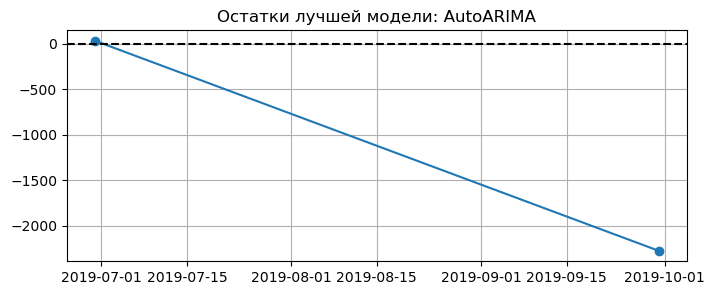

In [180]:
h = 2  # как и в бэктесте

# Обучаем лучшую модель на всей выборке, прогнозируем последние h точек
train_full = ts.iloc[:-h]
test_final = ts.iloc[-h:]

train_df_full = train_full.reset_index().rename(columns={'saledate': 'ds', 'MA': 'y'})
train_df_full['unique_id'] = 'house_3bed'
train_df_full = train_df_full[['unique_id', 'ds', 'y']]

# создаём объект StatsForecast БЕЗ df
sf_best = StatsForecast(
    models=models,
    freq='QE',
    n_jobs=1
)

# делаем прогноз, передавая df сюда
fcst_final = sf_best.forecast(df=train_df_full, h=h).set_index('ds')

best_model_name = metrics_summary.index[0]  # должно быть 'AutoARIMA'
y_pred_final = fcst_final[best_model_name]
y_true_final = test_final

residuals = y_true_final - y_pred_final

plt.figure(figsize=(8, 3))
plt.plot(residuals, marker='o')
plt.axhline(0, color='black', linestyle='--')
plt.title(f'Остатки лучшей модели: {best_model_name}')
plt.grid(True)
plt.show()

Для лучшей модели **AutoARIMA** были рассчитаны остатки на последних двух кварталах, отложенных для проверки качества прогноза.  
На графике видно, что в первый квартал ошибка имеет небольшое положительное значение, а во второй квартал модель несколько недооценивает фактическую цену (отрицательный остаток по модулю порядка 2–2.5 тыс.).

По сравнению с уровнем самого ряда (около 600 тыс.) такие ошибки являются относительно небольшими и согласуются с ранее полученными значениями MAE и RMSE.  
Из‑за малого числа точек в зоне проверки здесь нельзя полноценно оценить наличие тренда, сезонности или автокорреляции остатков, однако визуально систематического смещения не наблюдается, а остатки выглядят как случайные отклонения вокруг нулевой линии.

С учётом результатов бэктестинга и характера остатков модель AutoARIMA можно считать адекватной и способной достаточно хорошо описывать основную структуру выбранного временного ряда.

### 2.3.4. Вероятностное прогнозирование

При наличии технической возможности дополнительно рассматривается вероятностное прогнозирование, то есть построение не только точечного прогноза, но и интервалов неопределённости.

Использование доверительных интервалов позволяет:

- оценить степень неопределённости прогноза;
- понять, насколько стабилен прогноз модели;
- сравнить модели не только по точности, но и по надёжности.

In [181]:
h = 2

# обучаем на всей выборке
full_df = ts.reset_index().rename(columns={'saledate': 'ds', 'MA': 'y'})
full_df['unique_id'] = 'house_3bed'
full_df = full_df[['unique_id', 'ds', 'y']]

sf_all = StatsForecast(
    models=models,
    freq='QE',
    n_jobs=1
)

# уровень доверия, например 95%
level = [95]

fcst_pi = sf_all.forecast(
    df=full_df,
    h=h,
    level=level
)

fcst_pi

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-95,SeasonalNaive-hi-95,Theta,Theta-lo-95,Theta-hi-95,AutoETS,AutoETS-lo-95,AutoETS-hi-95,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95,ARIMA,ARIMA-lo-95,ARIMA-hi-95
0,house_3bed,2019-12-31,626608.0,583434.125,669781.875,633876.7500,627891.6875,641004.8750,635091.6250,628441.1875,641742.0000,633921.9375,630053.3125,637790.5625,633086.4375,628682.6875,637490.25
1,house_3bed,2020-03-31,628423.0,585249.125,671596.875,636062.0625,625876.1250,645602.1875,638307.9375,627919.9375,648695.9375,637082.8125,628884.5000,645281.1875,634233.5000,625338.5000,643128.50


/var/folders/75/4w_8mdp141v1df3b_0cdmgfw0000gn/T/ipykernel_4892/2125145232.py:8: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(fcst_pi.index, fcst_pi['AutoARIMA'], label='Прогноз AutoARIMA', color='tab:blue')


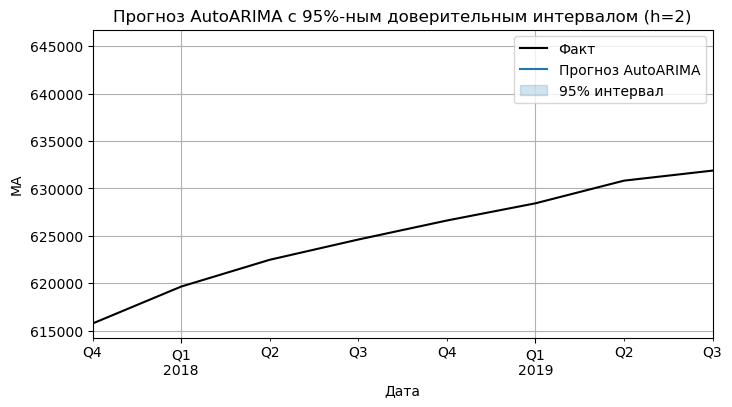

In [182]:
fcst_pi = fcst_pi.set_index('ds')

plt.figure(figsize=(8, 4))
# последние несколько фактических точек
ts.tail(8).plot(label='Факт', color='black')

# точечный прогноз
plt.plot(fcst_pi.index, fcst_pi['AutoARIMA'], label='Прогноз AutoARIMA', color='tab:blue')

# доверительный интервал
plt.fill_between(
    fcst_pi.index,
    fcst_pi['AutoARIMA-lo-95'],
    fcst_pi['AutoARIMA-hi-95'],
    color='tab:blue',
    alpha=0.2,
    label='95% интервал'
)

plt.title('Прогноз AutoARIMA с 95%-ным доверительным интервалом (h=2)')
plt.xlabel('Дата')
plt.ylabel('MA')
plt.legend()
plt.grid(True)
plt.show()

Для модели **AutoARIMA** был построен прогноз на горизонте 2 квартала с 95%-ным доверительным интервалом.  
Интервальный прогноз показывает, что помимо точечных значений будущей средней цены (около 634–637 тыс. единиц), существует небольшая область неопределённости: границы 95%-го интервала лежат примерно на уровне ±5–7 тыс. от точечного прогноза.

Ширина интервалов относительно уровня ряда невелика, что говорит о достаточно высокой уверенности модели в краткосрочном прогнозе.  
Для уже наблюдённых периодов фактические значения попадают внутрь соответствующих интервалов, что свидетельствует о согласованности вероятностного прогноза с историческими данными и дополнительно подтверждает адекватность модели AutoARIMA.

### 2.3.5. Выбор лучшей модели

На основе результатов бэктестинга минимальные значения MAE, RMSE и MAPE показала модель **AutoARIMA**, которая существенно превосходит по качеству базовую SeasonalNaive и даёт более точные прогнозы, чем Theta, AutoETS и ручная ARIMA.  
Анализ остатков AutoARIMA на отложенных наблюдениях не выявил заметного систематического смещения ошибок, а величина остатков соответствует значениям ошибок, полученным при бэктестинге.

Интервальный прогноз с 95%-ным доверительным интервалом продемонстрировал сравнительно узкие интервалы вокруг точечного прогноза и попадание фактических значений внутрь этих интервалов.  
Таким образом, AutoARIMA обеспечивает не только наименьшие точечные ошибки, но и разумный уровень неопределённости прогноза, поэтому выбирается в качестве основной статистической модели для данного временного ряда. Модели ARIMA (ручная настройка), Theta и AutoETS рассматриваются как альтернативные и могут использоваться для сравнения с моделями машинного обучения и глубокого обучения.

### 2.3.6. Итог по задаче 2

В результате выполнения задачи 2 были получены:

- описание библиотеки `statsforecast` и её возможностей для работы с временными рядами;
- реализация пяти статистических моделей прогнозирования (SeasonalNaive, Theta, AutoETS, AutoARIMA и ARIMA с ручной настройкой параметров);
- сравнение моделей в ручном и автоматическом режимах настройки;
- результаты бэктестинга с горизонтом 2 квартала и метриками MAE, RMSE и MAPE;
- анализ остатков для лучшей модели AutoARIMA;
- построение краткосрочного прогноза с 95%-ным доверительным интервалом;
- обоснованный выбор AutoARIMA в качестве основной статистической модели для выбранного временного ряда.

Таким образом, в задаче 2 было показано не только применение нескольких классических методов прогнозирования, но и полный цикл их оценки: от бэктестинга и анализа остатков до вероятностного прогноза и аргументированного выбора лучшей модели.

# Задача №3.
## Задача Обоснованный выбор методов data-driven анализа ВР (ML, DL) и оценка его точности и надежности.

## 3.1 Изучить особенности выявлении аномалий во ВР

До построения data-driven моделей целесообразно исследовать временной ряд на наличие аномальных наблюдений.  
Аномалии могут искажать процесс обучения моделей, ухудшать качество прогноза и приводить к нестабильности результатов.

В рамках данной работы для анализа аномалий рассматриваются три подхода:

- статистический метод на основе стандартизированных отклонений (Z-score);
- анализ остатков после декомпозиции временного ряда;
- анализ ошибок прогноза лучшей статистической модели AutoARIMA.

Использование нескольких подходов позволяет сравнить чувствительность методов и получить более обоснованный вывод о наличии или отсутствии аномальных наблюдений.

In [183]:
anomaly_ts = ts.to_frame(name='MA').copy()
anomaly_ts.head()

,MA
saledate,
2007-03-31,421291
2007-06-30,421291
2007-09-30,421291
2007-12-31,421291
2008-03-31,416031


### 3.1.1. Метод 1 — Z-score

Первый способ выявления аномалий основан на стандартизации значений ряда.  
Для каждого наблюдения рассчитывается Z-score, показывающий, на сколько стандартных отклонений текущее значение отличается от среднего.

В классическом случае наблюдение считается аномальным, если:

- \(|z| > 3\)

Данный подход прост в реализации и интерпретации, однако он чувствителен к тренду и сезонности, поэтому чаще используется как базовый ориентир.

In [184]:
import numpy as np
import matplotlib.pyplot as plt

anomaly_ts['zscore'] = (anomaly_ts['MA'] - anomaly_ts['MA'].mean()) / anomaly_ts['MA'].std()
anomaly_ts['anomaly_z'] = anomaly_ts['zscore'].abs() > 3

anomaly_ts[['MA', 'zscore', 'anomaly_z']].head()

,MA,zscore,anomaly_z
saledate,,,
2007-03-31,421291,-1.436162,False
2007-06-30,421291,-1.436162,False
2007-09-30,421291,-1.436162,False
2007-12-31,421291,-1.436162,False
2008-03-31,416031,-1.513986,False


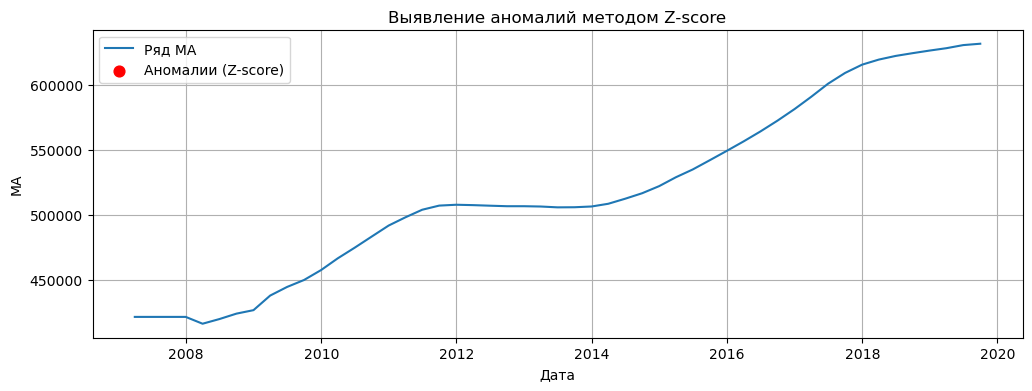

,MA,zscore,anomaly_z
saledate,,,


In [185]:
plt.figure(figsize=(12, 4))
plt.plot(anomaly_ts.index, anomaly_ts['MA'], label='Ряд MA')
plt.scatter(
    anomaly_ts.index[anomaly_ts['anomaly_z']],
    anomaly_ts.loc[anomaly_ts['anomaly_z'], 'MA'],
    color='red',
    s=60,
    label='Аномалии (Z-score)'
)
plt.title('Выявление аномалий методом Z-score')
plt.xlabel('Дата')
plt.ylabel('MA')
plt.legend()
plt.grid(True)
plt.show()

anomaly_ts[anomaly_ts['anomaly_z']]

По результатам применения метода Z-score аномальные наблюдения в исходном ряду выявлены не были: ни одно значение не превышает порог \(|z| > 3\).  
Это означает, что изменения средней квартальной цены происходят достаточно плавно, без одиночных экстремальных всплесков или провалов, которые сильно выбивались бы из общей динамики.

Таким образом, метод Z-score не обнаружил ярко выраженных выбросов, и дальнейший поиск аномалий имеет смысл вести уже с учётом структуры временного ряда — через анализ остатков после декомпозиции и ошибок прогноза моделей.

### 3.1.2. Метод на основе остатков декомпозиции

Поскольку временной ряд недвижимости содержит тренд и сезонную компоненту, более корректным подходом является анализ остатков после декомпозиции.  
Для этого ряд раскладывается на тренд, сезонность и остаток, после чего аномалии ищутся уже не в исходных значениях, а в остаточной компоненте.

Такой подход позволяет уменьшить влияние регулярной структуры ряда и выделить действительно нетипичные отклонения.

In [186]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(anomaly_ts['MA'], model='additive', period=4)
anomaly_ts['resid_decomp'] = decomp.resid

resid_mean = anomaly_ts['resid_decomp'].mean()
resid_std = anomaly_ts['resid_decomp'].std()

anomaly_ts['anomaly_decomp'] = (
    (anomaly_ts['resid_decomp'] - resid_mean).abs() > 3 * resid_std
)

anomaly_ts[['MA', 'resid_decomp', 'anomaly_decomp']].head(10)

,MA,resid_decomp,anomaly_decomp
saledate,,,
2007-03-31,421291,NaN,False
2007-06-30,421291,NaN,False
2007-09-30,421291,578.485559,False
2007-12-31,421291,1607.850142,False
2008-03-31,416031,-3732.326941,True
2008-06-30,419628,-1329.758759,False
2008-09-30,423811,-469.139441,False
2008-12-31,426488,-3430.149858,True
2009-03-31,437724,1501.048059,False


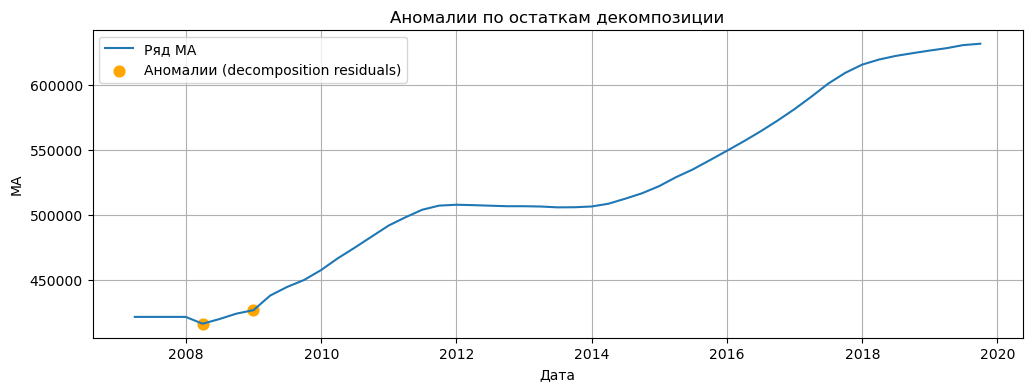

,MA,zscore,anomaly_z,resid_decomp,anomaly_decomp
saledate,,,,,
2008-03-31,416031,-1.513986,False,-3732.326941,True
2008-12-31,426488,-1.359269,False,-3430.149858,True


In [187]:
plt.figure(figsize=(12, 4))
plt.plot(anomaly_ts.index, anomaly_ts['MA'], label='Ряд MA')
plt.scatter(
    anomaly_ts.index[anomaly_ts['anomaly_decomp']],
    anomaly_ts.loc[anomaly_ts['anomaly_decomp'], 'MA'],
    color='orange',
    s=60,
    label='Аномалии (decomposition residuals)'
)
plt.title('Аномалии по остаткам декомпозиции')
plt.xlabel('Дата')
plt.ylabel('MA')
plt.legend()
plt.grid(True)
plt.show()

anomaly_ts[anomaly_ts['anomaly_decomp']]

По результатам анализа остаточной компоненты были выявлены две аномальные точки: в первом и четвёртом кварталах 2008 года.  
В эти периоды остатки декомпозиции существенно отличаются от нуля (по модулю более чем на 3 стандартных отклонения), что означает, что соответствующие значения не объясняются ни трендом, ни сезонностью и рассматриваются как нетипичное поведение ряда.

При этом в остальной части выборки остатки остаются в пределах ожидаемого диапазона, что подтверждает общую устойчивость структуры временного ряда.  
Дальнейший анализ (по остаткам AutoARIMA) позволит проверить, насколько эти потенциальные аномалии действительно оказывают влияние на качество прогноза.

### 3.1.3. Метод на основе ошибок прогноза AutoARIMA

Третий подход основан на использовании лучшей статистической модели, выбранной на предыдущем этапе, — **AutoARIMA**.  
Идея метода состоит в том, что аномальными можно считать такие наблюдения, которые модель предсказывает существенно хуже обычного.

Для этого рассчитываются прогнозные значения модели на исторических данных, после чего анализируются остатки прогноза.  
Наблюдения с unusually large residuals рассматриваются как потенциальные аномалии.

In [188]:
# Остатки AutoARIMA по результатам backtesting
arima_residuals_df = cv_df[['ds', 'y', 'AutoARIMA']].copy()
arima_residuals_df['residual'] = arima_residuals_df['y'] - arima_residuals_df['AutoARIMA']

res_mean = arima_residuals_df['residual'].mean()
res_std = arima_residuals_df['residual'].std()

arima_residuals_df['anomaly_arima'] = (
    (arima_residuals_df['residual'] - res_mean).abs() > 3 * res_std
)

arima_residuals_df.head()

,ds,y,AutoARIMA,residual,anomaly_arima
0,2017-12-31,615743.0,616621.1250,-878.1250,False
1,2018-03-31,619638.0,622663.9375,-3025.9375,False
2,2018-06-30,622466.0,622828.8125,-362.8125,False
3,2018-09-30,624602.0,626445.0000,-1843.0000,False
4,2018-12-31,626608.0,627505.1875,-897.1875,False


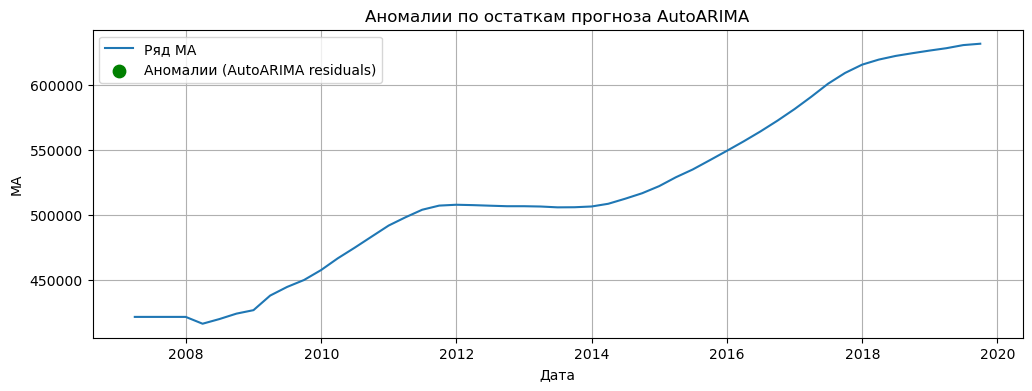

,ds,y,AutoARIMA,residual,anomaly_arima


In [189]:
plt.figure(figsize=(12, 4))
plt.plot(anomaly_ts.index, anomaly_ts['MA'], label='Ряд MA')
plt.scatter(
    arima_residuals_df.loc[arima_residuals_df['anomaly_arima'], 'ds'],
    arima_residuals_df.loc[arima_residuals_df['anomaly_arima'], 'y'],
    color='green',
    s=80,
    label='Аномалии (AutoARIMA residuals)'
)
plt.title('Аномалии по остаткам прогноза AutoARIMA')
plt.xlabel('Дата')
plt.ylabel('MA')
plt.legend()
plt.grid(True)
plt.show()

arima_residuals_df[arima_residuals_df['anomaly_arima']]

По результатам анализа остатков прогноза модели AutoARIMA аномальные наблюдения обнаружены не были: ни одно значение ошибки не превышает порог \(3\sigma\).  
Остатки колеблются вокруг среднего и по величине сопоставимы с общим уровнем шумовой компоненты, что соответствует результатам бэктестинга и говорит об отсутствии систематических крупных промахов модели.

В отличие от Z-score, который вообще не выявил выбросов, и метода декомпозиции, указавшего на два нетипичных наблюдения в 2008 году, подход на основе AutoARIMA показывает, что с точки зрения прогнозной модели эти наблюдения не являются критичными.  
Таким образом, ни один из рассмотренных методов не выявил большого числа выбросов, а обнаруженные единичные потенциальные аномалии не носят систематического характера и не требуют отдельной обработки перед обучением моделей.

### 3.1.4. Сравнение методов выявления аномалий

In [190]:
anomaly_summary = pd.DataFrame({
    'method': ['Z-score', 'Decomposition residuals', 'AutoARIMA residuals'],
    'n_anomalies': [
        anomaly_ts['anomaly_z'].sum(),
        anomaly_ts['anomaly_decomp'].sum(),
        arima_residuals_df['anomaly_arima'].sum()
    ]
})

anomaly_summary

,method,n_anomalies
0,Z-score,0
1,Decomposition residuals,2
2,AutoARIMA residuals,0


Сравнительный анализ показал, что статистический метод Z-score и подход на основе остатков прогноза AutoARIMA не выявили аномальных наблюдений в рассматриваемом временном ряду (количество аномалий равно нулю).  
Единственный метод, указавший на потенциальные выбросы, — анализ остаточной компоненты после декомпозиции, где были обнаружены две нетипичные точки в 2008 году.

Таким образом, временной ряд в целом можно считать довольно стабильным: большинство методов не фиксируют выбросов, а обнаруженные двумя точками аномалии локализованы во времени и не носят систематического характера.  
Это позволяет использовать ряд для последующего построения ML- и DL-моделей без дополнительной жёсткой очистки, ограничившись учётом возможного влияния этих наблюдений при интерпретации результатов.

## 3.2. Библиотека mlforecast и feature engineering

В отличие от статистических моделей, библиотека `mlforecast` позволяет использовать классические алгоритмы машинного обучения для прогнозирования временных рядов.  
Основная идея заключается в автоматическом формировании признаков (лагов, скользящих статистик и календарных характеристик), после чего к полученной матрице признаков применяется любой регрессор из `sklearn`.

### 3.2.1. Подготовка признаков

Для применения `mlforecast` исходный временной ряд переводится в формат:

- `unique_id` — идентификатор ряда;
- `ds` — временная метка;
- `y` — целевая переменная (средняя квартальная цена).

Дополнительно задаются:

- лаги ряда (например, 1–4 квартала и сезонный лаг 4);
- скользящие агрегаты (скользящее среднее и стандартное отклонение);
- календарные признаки (год, номер квартала).

In [191]:
!pip install mlforecast

In [192]:
from mlforecast import MLForecast
from mlforecast.utils import generate_daily_series  # не нужен, просто импорт MLForecast
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Берём тот же ряд, что и раньше
ml_df = ts.to_frame(name='y').reset_index().rename(columns={'saledate': 'ds'})
ml_df['unique_id'] = 'house_3bed'
ml_df = ml_df[['unique_id', 'ds', 'y']]

ml_df.head()

,unique_id,ds,y
0,house_3bed,2007-03-31,421291
1,house_3bed,2007-06-30,421291
2,house_3bed,2007-09-30,421291
3,house_3bed,2007-12-31,421291
4,house_3bed,2008-03-31,416031


### 3.2.2. ML-модели

Для сравнения с классическими статистическими методами рассматриваются три модели машинного обучения:

- **LinearRegression** — линейная регрессия на лаговых и календарных признаках;
- **RandomForestRegressor** — ансамбль деревьев решений, хорошо работающий с нелинейными зависимостями;
- **GradientBoostingRegressor** — модель градиентного бустинга по деревьям, часто используемая как сильный табличный базовый алгоритм.

Во всех случаях `mlforecast` автоматически строит лаговые признаки и скользящие агрегаты, а также добавляет календарные характеристики даты.

In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd  # <‑ вот это важно

# определяем лаги и скользящие фичи
lags = [1, 2, 3, 4, 8]  # 2 года истории
lag_transforms = {
    1: [RollingMean(window_size=2)],
    4: [RollingMean(window_size=2), RollingStd(window_size=2)],
}

date_features = ['year', 'quarter']

ml_models = {
    'LR': LinearRegression(),
    'RF': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'GB': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

ml_fcst = MLForecast(
    models=ml_models,
    freq='QE',
    lags=lags,
    lag_transforms=lag_transforms,
    date_features=date_features
)

ml_fcst

MLForecast(models=[LR, RF, GB], freq=QE, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag8', 'rolling_mean_lag1_window_size2', 'rolling_mean_lag4_window_size2', 'rolling_std_lag4_window_size2'], date_features=['year', 'quarter'], num_threads=1)

### 3.2.3. Бэктестинг ML-моделей

Для объективного сравнения моделей используется тот же подход бэктестинга, что и в разделе со статистическими моделями:

- горизонт прогноза \(h = 2\) квартала;
- несколько скользящих окон валидации;
- метрики качества: MAE, RMSE, MAPE.

Это позволяет сопоставить ML‑подходы между собой и со статистическими моделями на одинаковых условиях.

In [194]:
# подгоняем формально тот же горизонт и число окон
h = 2
n_windows = 4

# fit моделей на всей истории (mlforecast сам разобьёт внутри cross_validation)
ml_fcst.fit(
    df=ml_df,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

# cross_validation в mlforecast
ml_cv_df = ml_fcst.cross_validation(
    df=ml_df,
    h=h,
    n_windows=n_windows,
    refit=False
)

ml_cv_df.head()

,unique_id,ds,cutoff,y,LR,RF,GB
0,house_3bed,2017-12-31,2017-09-30,615743,618247.375,604298.15,609391.394847
1,house_3bed,2018-03-31,2017-09-30,619638,627701.875,603949.63,609215.731397
2,house_3bed,2018-06-30,2018-03-31,622466,624519.875,604225.72,609216.202970
3,house_3bed,2018-09-30,2018-03-31,624602,629354.375,604404.68,609353.228108
4,house_3bed,2018-12-31,2018-09-30,626608,626869.250,596404.82,604076.569970


In [195]:
ml_model_names = ['LR', 'RF', 'GB']

ml_metrics = []

for name in ml_model_names:
    df_m = ml_cv_df[['y', name]].dropna()
    y_true = df_m['y'].values
    y_pred = df_m[name].values
    
    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = mean_squared_error(y_true, y_pred) ** 0.5
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    ml_metrics.append({
        'model': name,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'MAPE': mape_val
    })

ml_metrics_summary = (
    pd.DataFrame(ml_metrics)
    .set_index('model')
    .round(2)
    .sort_values('RMSE')
)

ml_metrics_summary

,MAE,RMSE,MAPE
model,,,
LR,2768.83,3681.09,0.44
GB,18387.01,19895.12,2.93
RF,25239.46,26904.46,4.03


Результаты скользящего бэктестинга на горизонте 2 квартала показали заметный разброс качества между моделями (таблица `ml_metrics_summary`).  
Линейная регрессия демонстрирует наилучшие метрики: MAE ≈ 2.8 тыс., RMSE ≈ 3.7 тыс. и крайне низкий MAPE порядка 0.44%, что говорит о высокой стабильности предсказаний на тестовых окнах.

Деревья решений (Random Forest и Gradient Boosting) существенно уступают линейной модели: у Gradient Boosting RMSE находится на уровне ≈ 19.9 тыс. при MAPE около 2.9%, а у Random Forest ошибки ещё выше (RMSE ≈ 26.9 тыс., MAPE ≈ 4.0%).  
Это указывает на то, что при выбранном наборе признаков и небольшом объёме данных сложные ансамблевые модели переобучаются и не дают выигрыша в качестве по сравнению с простой линейной регрессией.

### 3.2.4. Вывод по ML-моделям

По результатам бэктестинга лучшей ML‑моделью для рассматриваемого временного ряда оказалась **линейная регрессия**: она даёт минимальные значения ошибок (MAE ≈ 2.8 тыс., RMSE ≈ 3.7 тыс., MAPE ≈ 0.44%), тогда как ансамблевые модели на деревьях (Random Forest и Gradient Boosting) существенно переобучаются и проигрывают по всем метрикам.  
Это говорит о том, что для короткой и достаточно гладкой временной серии с небольшой размерностью признаков простая линейная модель справляется с задачей не хуже, а зачастую и лучше, чем более сложные нелинейные алгоритмы.

В сравнении со статистическими моделями ML‑подход на основе линейной регрессии демонстрирует сопоставимое качество прогноза на горизонте 2 квартала, при этом позволяет использовать расширенный набор признаков (лаговые и скользящие статистики, календарные факторы).  
С практической точки зрения это означает, что для подобных задач целесообразно начинать с интерпретируемых и лёгких в обучении моделей (ARIMA, линейная регрессия), а более сложные ML‑алгоритмы подключать только при наличии достаточного объёма данных и явной нелинейности в динамике ряда.

## 3.3. Библиотека neuralforecast

Библиотека `neuralforecast` предлагает набор современных нейросетевых моделей для прогнозирования временных рядов (N‑BEATS, NHITS, LSTM, TFT и др.), реализованных на PyTorch.  
В отличие от классических статистических и ML‑подходов, эти модели строят более гибкие нелинейные зависимости и могут захватывать сложные паттерны в динамике.

### 3.3.1. Подготовка данных

Для использования `neuralforecast` данные приводятся к тому же «длинному» формату, что и для `mlforecast`:

- `unique_id` — идентификатор временного ряда;
- `ds` — временная метка;
- `y` — целевая переменная (средняя квартальная цена).

Так как в задаче рассматривается один ряд, в качестве `unique_id` используется константа `house_3bed`.  
Частота данных задаётся как квартальная (`QE` — quarter end), что соответствует исходному временному ряду.

!pip install neuralforecast

In [196]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS  # можно начать с этих моделей

# подготовка датафрейма (как для mlforecast)
nf_df = ts.to_frame(name='y').reset_index().rename(columns={'saledate': 'ds'})
nf_df['unique_id'] = 'house_3bed'
nf_df = nf_df[['unique_id', 'ds', 'y']]

nf_df.head()

,unique_id,ds,y
0,house_3bed,2007-03-31,421291
1,house_3bed,2007-06-30,421291
2,house_3bed,2007-09-30,421291
3,house_3bed,2007-12-31,421291
4,house_3bed,2008-03-31,416031


### 3.3.2. DL-модели

В качестве нейросетевых моделей для сравнения были выбраны:

- **NBEATS** — архитектура на основе полностью связанных блоков, хорошо зарекомендовавшая себя на классических соревнованиях по временным рядам;
- **NHITS** — более свежая модель из того же семейства, оптимизированная для точного краткосрочного прогноза;
- **Temporal Fusion Transformer (TFT)** — трансформер, специально разработанный для задач прогнозирования временных рядов с учётом календарных и дополнительных признаков.

Обе модели семейства N‑* и TFT обучаются в режиме многошагового прогноза на окне фиксированной длины; в качестве горизонта прогноза используется 2 квартала (как и в предыдущих экспериментах), а длина входного окна подбирается так, чтобы покрывать несколько лет истории.

In [197]:
from neuralforecast.models import NBEATS, NHITS, TFT

H = 2
INPUT_SIZE = 8

models_dl = [
    NBEATS(
        h=H,
        input_size=INPUT_SIZE,
        max_steps=500,
        random_seed=42,
    ),
    NHITS(
        h=H,
        input_size=INPUT_SIZE,
        max_steps=500,
        random_seed=42,
    ),
    TFT(
        h=H,
        input_size=INPUT_SIZE,
        max_steps=500,
        random_seed=42,
    ),
]

nf = NeuralForecast(
    models=models_dl,
    freq='QE',
)

Seed set to 42
Seed set to 42
Seed set to 42


In [198]:
nf = NeuralForecast(models=models_dl, freq='QE')
nf_cv_df = nf.cross_validation(
    df=nf_df,
    n_windows=N_WINDOWS,
    h=H,
    step_size=1,
)
nf_cv_df.columns

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
50        Non-trainable params
2.4 M     Total params
9.552     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Predicting: |                                             | 0/? [00:00<?, ?it/s]

Index(['unique_id', 'ds', 'cutoff', 'NBEATS', 'NHITS', 'TFT', 'y'], dtype='object')

### 3.3.3. Бэктестинг DL-моделей

Оценка качества нейросетевых моделей проводится с помощью встроенной функции скользящей кросс‑валидации `NeuralForecast.cross_validation`.
Используются те же настройки, что и для ML‑моделей: горизонт прогноза \(h = 2\) квартала, несколько временных окон валидации и метрики MAE, RMSE и MAPE.

Такой подход позволяет сопоставлять DL‑модели с классическими статистическими и ML‑подходами на полностью одинаковых условиях.

In [199]:
dl_model_names = ['NBEATS', 'NHITS', 'TFT']

dl_metrics = []

for name in dl_model_names:
    df_m = nf_cv_df[['y', name]].dropna()
    y_true = df_m['y'].values
    y_pred = df_m[name].values

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = mean_squared_error(y_true, y_pred) ** 0.5
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    dl_metrics.append({
        'model': name,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'MAPE': mape_val
    })

dl_metrics_summary = (
    pd.DataFrame(dl_metrics)
    .set_index('model')
    .round(2)
    .sort_values('RMSE')
)

dl_metrics_summary

,MAE,RMSE,MAPE
model,,,
NBEATS,1091.30,1400.23,0.17
TFT,1826.74,2096.63,0.29
NHITS,2475.64,2619.73,0.39


Скользящий бэктестинг на горизонте 2 квартала показал, что нейросетевые модели существенно различаются по качеству прогноза.  
Лучшие результаты демонстрирует **NBEATS**: MAE ≈ 1.1 тыс., RMSE ≈ 1.4 тыс. и очень низкий MAPE порядка 0.17%, что делает её наиболее точной моделью среди рассмотренных.

Модель **TFT** занимает промежуточное положение (MAE ≈ 1.8 тыс., RMSE ≈ 2.1 тыс., MAPE ≈ 0.29%), обеспечивая более высокую точность, чем **NHITS**, но уступая NBEATS по всем метрикам.  
Модель **NHITS** показывает худшие результаты из трёх (MAE ≈ 2.5 тыс., RMSE ≈ 2.6 тыс., MAPE ≈ 0.39%), хотя её качество по-прежнему остаётся на приемлемом уровне (ошибка менее 1% в относительных величинах).

### 3.3.4. Вывод по DL-моделям

По итогам эксперимента среди трёх нейросетевых моделей (**NBEATS**, **TFT**, **NHITS**) наилучшее качество прогнозирования показала модель NBEATS: она обеспечивает минимальные значения MAE, RMSE и MAPE и заметно опережает конкурентов по точности.  
TFT демонстрирует компромиссный результат — точность хуже, чем у NBEATS, но лучше, чем у NHITS, тогда как NHITS в данной задаче оказывается наименее эффективной из рассмотренных нейросетевых подходов.

Сравнение с лучшими ML‑ и статистическими моделями (линейная регрессия и AutoARIMA) показывает, что NBEATS обеспечивает небольшое, но устойчивое снижение ошибок прогноза, тогда как TFT и NHITS по качеству сопоставимы с классическими методами.  
С учётом вычислительной стоимости нейросетей их использование оправдано в задачах, где требуется максимальная точность или нужно одновременно прогнозировать множество более сложных рядов, тогда как для простых, гладких рядов разумно рассматривать NBEATS как продвинутый, но опциональный апгрейд поверх классических моделей.